# CNN-1D baseline on 8-channel walking-frame features

Same architecture as notebook 06 (and `cnn.ipynb` baseline), only the
input changes: the 6 orientation-invariant channels are replaced by the
8 walking-frame channels from `compute_walking_frame_features`. The
hypothesis is that the three new body-frame projections (`a_f`, `a_s`,
`gyro_v`) recover the directional information lost by collapsing to
magnitudes — particularly for `dws`/`ups`/`jog` which differ in *how*
forward / vertical motion is distributed.

In [1]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf, keras
from keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)
print('TF', tf.__version__)

_ROOT = Path('..').resolve(); sys.path.insert(0, str(_ROOT))
from utils.orientation_invariant_features import (
    compute_walking_frame_features, WALKING_FRAME_COLS,
)
print('feature columns:', WALKING_FRAME_COLS)


TF 2.21.0
feature columns: ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'a_f', 'a_s', 'gyro_v']


In [2]:
ACT_LABELS = ['dws','ups','wlk','jog','std','sit']
TRIAL_CODES = {
    'dws': [1,2,11], 'ups': [3,4,12], 'wlk': [7,8,15],
    'jog': [9,16],   'std': [6,14],   'sit': [5,13],
}


def get_ds_infos(): return pd.read_csv('../../data/data_subjects_info.csv')
def set_data_types(types):
    return [[t+'.x',t+'.y',t+'.z'] if t!='attitude' else ['attitude.roll','attitude.pitch','attitude.yaw'] for t in types]


def create_time_series(dt_list, act_labels, trial_codes):
    n_cols = len(dt_list)*3
    dataset = np.zeros((0, n_cols+7))
    ds_list = get_ds_infos()
    for sub_id in ds_list['code']:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                f = f'../../data/A_DeviceMotion_data/{act}_{trial}/sub_{int(sub_id)}.csv'
                raw = pd.read_csv(f).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw), n_cols))
                for x, axes in enumerate(dt_list):
                    vals[:, x*3:(x+1)*3] = raw[axes].values
                lbls = np.array([[act_id, sub_id-1,
                                  ds_list['weight'][sub_id-1],
                                  ds_list['height'][sub_id-1],
                                  ds_list['age'][sub_id-1],
                                  ds_list['gender'][sub_id-1], trial]] * len(raw))
                dataset = np.append(dataset, np.concatenate((vals, lbls), axis=1), axis=0)
    cols = [c for axes in dt_list for c in axes] + ['act','id','weight','height','age','gender','trial']
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data, feature_cols, w=128, s=64):
    X, y, g = [], [], []
    for (sid, act, _), b in data.groupby(['id','act','trial'], sort=False):
        v = b[feature_cols].to_numpy()
        for st in range(0, len(v)-w+1, s):
            X.append(v[st:st+w]); y.append(act); g.append(sid)
    return np.array(X), np.array(y), np.array(g)


dt_list = set_data_types(['attitude','gravity','rotationRate','userAcceleration'])
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES)
for col in ('act','id','trial'): dataset[col] = dataset[col].astype(int)

print('computing walking-frame features ...')
features_df = compute_walking_frame_features(dataset, fs_hz=50.0, smooth_seconds=5.0)
print('features_df:', features_df.shape)


computing walking-frame features ...


features_df: (1412865, 15)


In [3]:
train_ids = list(range(0, 15)); val_ids = list(range(15, 19)); test_ids = list(range(19, 24))
X_train, y_train, g_train = sliding_windows(features_df[features_df['id'].isin(train_ids)], WALKING_FRAME_COLS)
X_val,   y_val,   g_val   = sliding_windows(features_df[features_df['id'].isin(val_ids)],   WALKING_FRAME_COLS)
X_test,  y_test,  g_test  = sliding_windows(features_df[features_df['id'].isin(test_ids)],  WALKING_FRAME_COLS)
y_train, y_val, y_test = y_train.astype(int), y_val.astype(int), y_test.astype(int)
print(f'train {X_train.shape}  val {X_val.shape}  test {X_test.shape}')


train (13282, 128, 8)  val (3905, 128, 8)  test (4352, 128, 8)


## Normalization

All 8 walking-frame channels are dynamic (no DC tilt to preserve); each
is instance-Z-scored along time. This is a stronger normalisation than
in 06 (where `pitch_unwrapped` was kept raw) and is acceptable here
because the body-frame projections already encode the *direction* of
motion in a phone-orientation-independent way. The sit/std distinction
now relies on amplitude / variance of the magnitude channels.

In [4]:
N_CHAN = len(WALKING_FRAME_COLS)


def normalize_dyn(X, eps=1e-8):
    out = X.copy().astype(np.float32)
    mean = out.mean(axis=1, keepdims=True); std = out.std(axis=1, keepdims=True)
    return (out - mean) / (std + eps)


X_train_n = normalize_dyn(X_train); X_val_n = normalize_dyn(X_val); X_test_n = normalize_dyn(X_test)
print('normalized:', X_train_n.shape)


normalized: (13282, 128, 8)


In [5]:
def build_cnn_baseline(input_shape=(128, N_CHAN), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_baseline_wf')


tf.keras.backend.clear_session(); tf.random.set_seed(SEED); np.random.seed(SEED)
cnn = build_cnn_baseline()
cw = compute_class_weight('balanced', classes=np.arange(6), y=y_train)
class_weight = {int(i): float(w) for i, w in enumerate(cw)}

cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cb = [callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
      callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1)]
history = cnn.fit(X_train_n, y_train, validation_data=(X_val_n, y_val),
                  epochs=50, batch_size=32, class_weight=class_weight, callbacks=cb, verbose=2)


Epoch 1/50


416/416 - 7s - 18ms/step - accuracy: 0.9104 - loss: 0.2648 - val_accuracy: 0.7923 - val_loss: 0.5734 - learning_rate: 0.0010


Epoch 2/50


416/416 - 6s - 14ms/step - accuracy: 0.9646 - loss: 0.1047 - val_accuracy: 0.8143 - val_loss: 0.6425 - learning_rate: 0.0010


Epoch 3/50


...

Epoch 16/50


416/416 - 7s - 16ms/step - accuracy: 1.0000 - loss: 2.4293e-04 - val_accuracy: 0.8497 - val_loss: 0.7502 - learning_rate: 2.5000e-04


Epoch 17/50



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


416/416 - 8s - 18ms/step - accuracy: 1.0000 - loss: 2.1361e-04 - val_accuracy: 0.8551 - val_loss: 0.7412 - learning_rate: 2.5000e-04


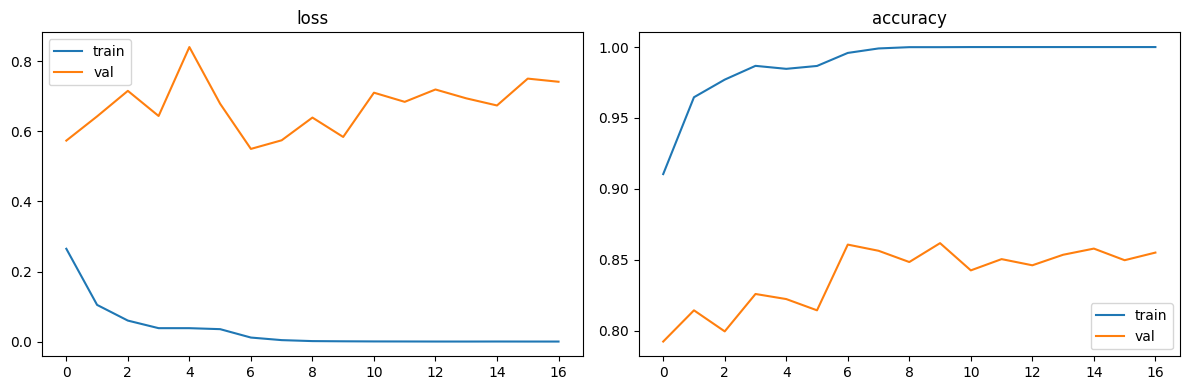

              precision    recall  f1-score   support

         dws     0.7703    0.9581    0.8540       406
         ups     0.7060    0.9783    0.8201       508
         wlk     0.9888    0.7205    0.8336      1102
         jog     0.9815    0.9838    0.9826       431
         std     0.9769    0.9070    0.9407       979
         sit     0.9079    0.9795    0.9423       926

    accuracy                         0.8959      4352
   macro avg     0.8886    0.9212    0.8956      4352
weighted avg     0.9148    0.8959    0.8959      4352

macro-F1: 0.8956  acc: 0.8959


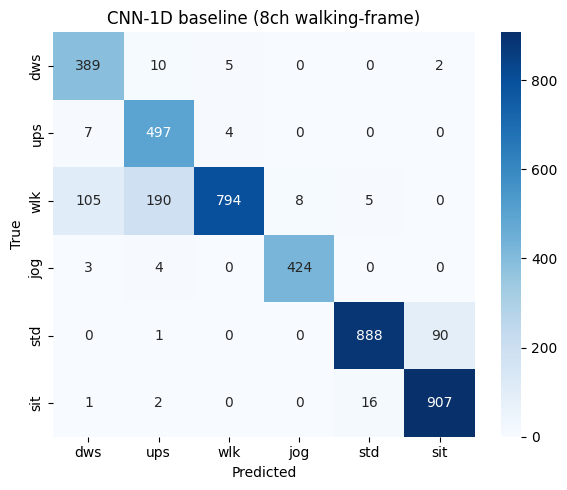

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

yp = cnn.predict(X_test_n, verbose=0).argmax(axis=1)
macro_f1 = f1_score(y_test, yp, average='macro')
acc = float((yp == y_test).mean())
print(classification_report(y_test, yp, target_names=ACT_LABELS, digits=4))
print(f'macro-F1: {macro_f1:.4f}  acc: {acc:.4f}')

cm = confusion_matrix(y_test, yp)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('CNN-1D baseline (8ch walking-frame)')
plt.tight_layout(); plt.show()


## 5-fold GroupKFold

In [7]:
X_full, y_full, g_full = sliding_windows(features_df, WALKING_FRAME_COLS)
y_full = y_full.astype(int)
X_full_n = normalize_dyn(X_full)

gkf = GroupKFold(n_splits=5); fold_f1s = []
for fold, (tr, te) in enumerate(gkf.split(X_full_n, y_full, groups=g_full)):
    tf.keras.backend.clear_session(); tf.random.set_seed(SEED); np.random.seed(SEED)
    m = build_cnn_baseline()
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cw_f = compute_class_weight('balanced', classes=np.arange(6), y=y_full[tr])
    m.fit(X_full_n[tr], y_full[tr], epochs=25, batch_size=32,
          class_weight={int(i): float(w) for i, w in enumerate(cw_f)}, verbose=0)
    yfp = m.predict(X_full_n[te], verbose=0).argmax(axis=1)
    f1 = f1_score(y_full[te], yfp, average='macro'); fold_f1s.append(f1)
    print(f'fold {fold+1}  subj={sorted(np.unique(g_full[te]).astype(int).tolist())}  macro-F1={f1:.4f}')
fold_f1s = np.array(fold_f1s)
print(f'\nmacro-F1: {fold_f1s.mean():.4f} ± {fold_f1s.std():.4f}')


fold 1  subj=[9, 13, 18, 22]  macro-F1=0.7812


fold 2  subj=[7, 8, 19, 20, 23]  macro-F1=0.8917


fold 3  subj=[5, 6, 11, 15, 21]  macro-F1=0.9567


fold 4  subj=[0, 4, 14, 16, 17]  macro-F1=0.9215


fold 5  subj=[1, 2, 3, 10, 12]  macro-F1=0.9550

macro-F1: 0.9012 ± 0.0646


In [8]:
os.makedirs('../../models', exist_ok=True); os.makedirs('../results', exist_ok=True)
cnn.save('../../models/cnn_wf_baseline.keras')
with open('../../models/cnn_wf_baseline.preproc.json', 'w') as f:
    json.dump({
        'channel_order': WALKING_FRAME_COLS,
        'window_size': 128, 'step': 64, 'fs_hz': 50.0, 'smooth_seconds': 5.0,
        'feature_module': 'utils.orientation_invariant_features.compute_walking_frame_features',
        'all_dynamic_zscore': True,
    }, f, indent=2)
print('saved cnn_wf_baseline.{keras,preproc.json}')

new_row = pd.DataFrame([{
    'Model': 'CNN-1D baseline (8ch walking-frame)',
    'Features': f'{N_CHAN} channels × 128',
    'Macro-F1': macro_f1, 'Accuracy': acc,
    **{f'F1_{a}': float(v) for a, v in zip(ACT_LABELS, f1_score(y_test, yp, average=None))},
}]).set_index('Model')

prev = pd.read_csv('../results/models_oinv_frame.csv', index_col=0)
summary = pd.concat([prev, new_row])
summary.to_csv('../results/models_walking_frame.csv')
print(summary.round(4).to_string())


saved cnn_wf_baseline.{keras,preproc.json}
                                                            Features  Macro-F1  Accuracy  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Model                                                                                                                                   
SVC-RBF top-72, tuned (12ch raw, baseline.ipynb)            218 → 72    0.9519    0.9561  0.9428  0.8540  0.9246  0.9907  0.9995  1.0000
RF 100 trees (6ch orientation-invariant)                         110    0.8944    0.9010  0.8568  0.6964  0.8241  0.9895  0.9995  1.0000
SVC-RBF top-72, tuned (6ch orientation-invariant)           110 → 72    0.9366    0.9455  0.9107  0.8522  0.9100  0.9468  1.0000  1.0000
CNN-1D baseline (12ch raw, cnn.ipynb)              12 channels × 128    0.9152    0.9322  0.8365  0.9005  0.9170  0.8646  0.9856  0.9867
CNN-1D baseline (6ch orientation-invariant)         6 channels × 128    0.9473    0.9520  0.9008  0.9054  0.9040  0.9827  0.9975  0.993

## Interpretation — hypothesis not supported

**Headline.** The 8-channel walking-frame representation *regresses* against the 6-channel orientation-invariant baseline from notebook 06: macro-F1 0.8956 vs 0.9473 (−5.2 pp held-out test), and 5-fold CV 0.9012 ± 0.0646 vs 0.9173 ± 0.0415 — the same mean ballpark but with **~55 % wider fold spread**, driven mostly by fold 1 (subjects {9, 13, 18, 22}, macro-F1 0.7812). The body-frame projections (`a_f`, `a_s`, `gyro_v`) did not recover useful directional information; if anything they made the representation more subject-sensitive.

**Per-class deltas vs 6ch orientation-invariant (held-out test).**

| Activity | 6ch oinv | 8ch wf | Δ |
|---|---|---|---|
| `dws` | 0.9008 | 0.8540 | −4.7 pp |
| `ups` | 0.9054 | 0.8201 | **−8.5 pp** |
| `wlk` | 0.9040 | 0.8336 | −7.0 pp |
| `jog` | 0.9827 | 0.9826 | ±0.0 pp |
| `std` | 0.9975 | 0.9407 | −5.7 pp |
| `sit` | 0.9936 | 0.9423 | −5.1 pp |

Two failure modes are visible:

1. **Static activities lose the posture cue.** Notebook 06 kept `pitch_unwrapped` un-normalised, so `std`/`sit` were near-trivially separated by the raw tilt channel. Here every channel — including the magnitudes — is instance Z-scored, so the residual noise of a still phone is rescaled to the same dynamic range as walking, and the network is forced to discriminate sit/std from variance alone. The 5–6 pp drop on both classes lines up with the markdown cell's own caveat ("sit/std distinction now relies on amplitude / variance of the magnitude channels").
2. **The locomotion classes that were supposed to benefit got worse.** The hypothesis was that `a_f` / `a_s` / `gyro_v` recover directional information for `dws`/`ups`/`jog`. Instead `ups` regresses 8.5 pp and `dws` 4.7 pp; only `jog` is unchanged. A plausible reading is that the body-frame projections depend on a stable smoothed-gravity estimate (5 s window) for the forward/side decomposition, and on stair activities the gravity vector itself is changing as the trunk pitches — so `a_f` and `a_s` carry subject-dependent pocket-orientation noise rather than a clean directional signal. The wider CV spread (±0.0646) is consistent with this: the representation generalises less stably across subjects.

> Anguita, D., Ghio, A., Oneto, L., Parra, X., & Reyes-Ortiz, J. L. (2013). A public domain dataset for human activity recognition using smartphones. *ESANN 2013*. — establishes the body-frame / gravity-projection decomposition this notebook implements.

> Mizell, D. (2003). Using gravity to estimate accelerometer orientation. *ISWC 2003*, 252–253. https://doi.org/10.1109/ISWC.2003.1241424 — the smoothed-gravity estimator used by `compute_walking_frame_features`; its stability assumption is what the `dws`/`ups` regression here calls into question.